#**Challenge Telecom X - Fase 2: Análisis de Cohortes**

# 📊 **Fase 1: Configuración del Entorno y Carga de Datos**
En esta fase preparamos el entorno de trabajo importando las bibliotecas necesarias para el análisis estadístico y Machine Learning. Recuperamos los datos procesados mediante la API de GitHub para asegurar la trazabilidad del proyecto.

In [17]:
# 1.1. Importación de bibliotecas esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import chi2

# 1.2. Extracción y Consolidación del Dataset
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    response = requests.get(url)
    response.raise_for_status()
    # Normalización exacta respetando la jerarquía de la Fase 1
    df_consolidado = pd.json_normalize(response.json())
    print(f"✅ Éxito: Se han extraído {len(df_consolidado)} registros correctamente.")
except Exception as e:
    print(f"❌ Error en la conexión: {e}")

✅ Éxito: Se han extraído 7267 registros correctamente.


# 🛠️ **Fase 2: Preparación de Datos y Auditoría de Clases**
Realizamos la limpieza adicional necesaria para el modelado predictivo. En esta etapa verificamos la proporción de cancelación (Churn) para identificar posibles desbalances en los datos, asegurando que la base de datos sea íntegra y esté lista para el análisis estadístico.

## **2.1. Casting de variables financieras y tratamiento de nulos**
En este paso, aseguramos que las columnas de cargos mensuales y totales sean tratadas como números (float). Además, gestionamos los posibles valores nulos o espacios en blanco que podrían generar errores en el análisis estadístico posterior.

In [20]:
# 2.1. Conversión a tipos numéricos y llenado de nulos
df_consolidado['account.Charges.Total'] = pd.to_numeric(df_consolidado['account.Charges.Total'], errors='coerce').fillna(0)
df_consolidado['account.Charges.Monthly'] = pd.to_numeric(df_consolidado['account.Charges.Monthly'], errors='coerce')

print("✅ Casting completado: Las variables financieras ahora son de tipo numérico.")

✅ Casting completado: Las variables financieras ahora son de tipo numérico.



## **2.2. Codificación de la Variable Objetivo (Churn)**
Para realizar cálculos estadísticos y entrenar modelos de Machine Learning, transformamos la columna 'Churn' de texto ('Yes'/'No') a un formato binario (1/0). Esto permite al sistema procesar la variable como un valor numérico.

In [23]:
# 2.2. Creación de la columna numérica para Churn
df_consolidado['Churn_Numeric'] = df_consolidado['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

print("✅ Codificación completada: 'Churn_Numeric' lista para análisis (1 = Yes, 0 = No).")

✅ Codificación completada: 'Churn_Numeric' lista para análisis (1 = Yes, 0 = No).


## **2.3. Verificación de proporción de clases y visualización**
Analizamos el balance del conjunto de datos verificando cuántos clientes permanecen frente a cuántos cancelan el servicio. Este paso es fundamental para identificar si el dataset está balanceado antes de proceder con el modelado.

--- REPORTE DE PROPORCIÓN DE CANCELACIÓN ---
Churn_Numeric
0    74.280996
1    25.719004
Name: proportion, dtype: float64


/tmp/ipykernel_398/455672805.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_consolidado, palette='viridis')


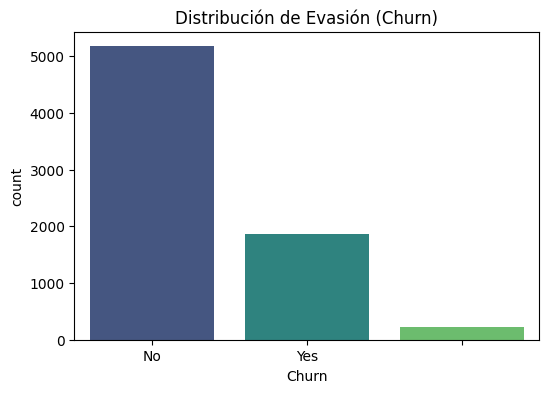

In [22]:
# 2.3. Análisis de frecuencia y visualización del Churn
proporcion = df_consolidado['Churn_Numeric'].value_counts(normalize=True) * 100
print(f"--- REPORTE DE PROPORCIÓN DE CANCELACIÓN ---\n{proporcion}")

# Generación del gráfico de distribución
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_consolidado, palette='viridis')
plt.title('Distribución de Evasión (Churn)')
plt.show()

# 📈 **Fase 3: Análisis de Correlación y Regresión Lineal**
En esta fase aplicamos conceptos fundamentales de estadística descriptiva e inferencial. El objetivo es identificar los "drivers" o factores que tienen mayor relación con la cancelación de clientes y modelar el comportamiento del crecimiento financiero en función del tiempo.


## **3.1. Matriz de Correlación de Variables Críticas**
Calculamos el coeficiente de correlación para entender la fuerza y dirección de la relación entre las variables numéricas y el Churn. Esto nos permite visualizar qué variables (como cargos mensuales o antigüedad) impactan más en la lealtad del cliente.

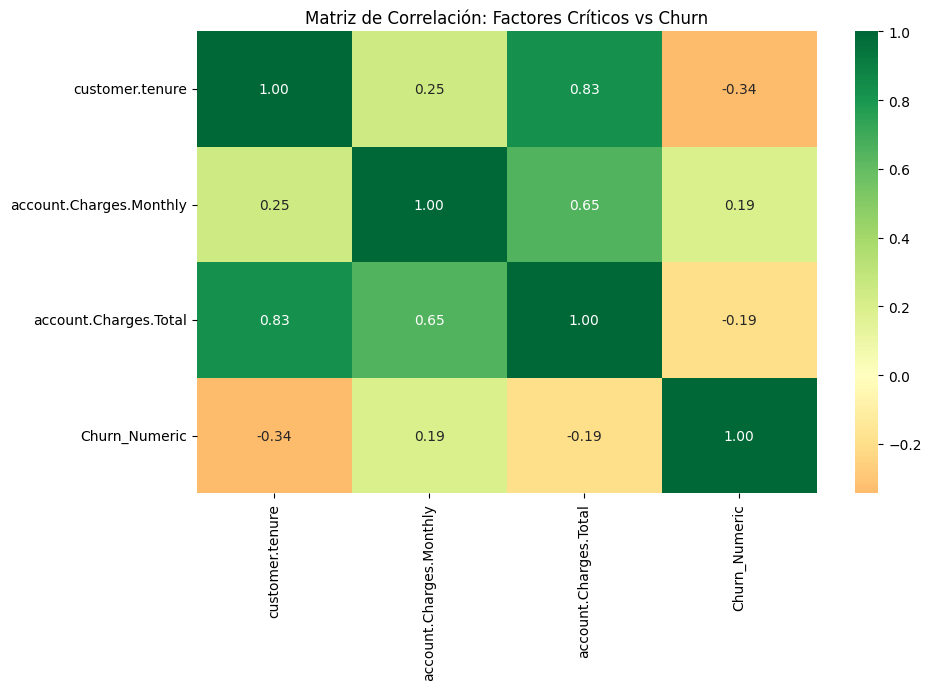

In [24]:
# 3.1. Generación de Mapa de Calor de Correlación
cols_est = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Churn_Numeric']

plt.figure(figsize=(10, 6))
sns.heatmap(df_consolidado[cols_est].corr(), annot=True, cmap='RdYlGn', fmt='.2f', center=0)
plt.title('Matriz de Correlación: Factores Críticos vs Churn')
plt.show()

## **3.2. Regresión Lineal: Relación Antigüedad vs Cargos Totales**
Modelamos la relación entre el tiempo (tenure) y los ingresos totales generados. La regresión lineal nos permite observar la tendencia de crecimiento del valor del cliente y cómo la empresa acumula ingresos a lo largo de la vida del contrato.

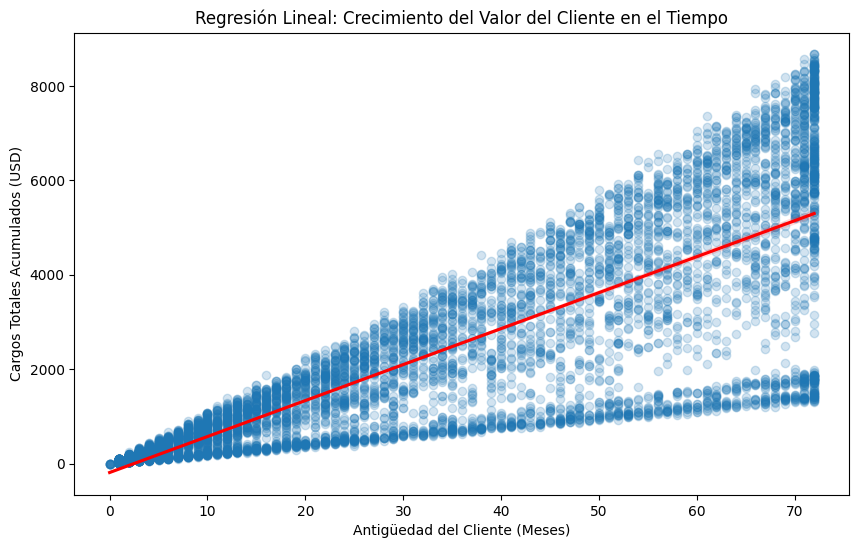

In [25]:
# 3.2. Modelado de tendencia mediante Regresión Lineal
plt.figure(figsize=(10, 6))
sns.regplot(x='customer.tenure', y='account.Charges.Total', data=df_consolidado,
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})

plt.title('Regresión Lineal: Crecimiento del Valor del Cliente en el Tiempo')
plt.xlabel('Antigüedad del Cliente (Meses)')
plt.ylabel('Cargos Totales Acumulados (USD)')
plt.show()

## **3.3. Prueba de Independencia Qui-cuadrado ($\chi^2$)**
Para las variables que no son numéricas (servicios, género, contrato), aplicamos la prueba Qui-cuadrado. Esta nos indica, mediante el p-value, si la relación entre esa variable y el Churn es estadísticamente significativa o si es fruto del azar.

In [26]:
# 3.3. Análisis de importancia estadística para variables categóricas
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

df_chi = df_consolidado.copy()
le = LabelEncoder()

for col in df_chi.select_dtypes(include=['object']).columns:
    df_chi[col] = le.fit_transform(df_chi[col].astype(str))

X_chi = df_chi.drop(columns=['customerID', 'Churn', 'Churn_Numeric'])
y_chi = df_chi['Churn_Numeric']

chi_scores, p_values = chi2(X_chi, y_chi)
chi_ranking = pd.DataFrame({'Variable': X_chi.columns, 'p-value': p_values}).sort_values(by='p-value')

print("--- TOP VARIABLES CON SIGNIFICANCIA ESTADÍSTICA (p < 0.05) ---")
print(chi_ranking[chi_ranking['p-value'] < 0.05].head(10))

--- TOP VARIABLES CON SIGNIFICANCIA ESTADÍSTICA (p < 0.05) ---
                     Variable        p-value
4             customer.tenure   0.000000e+00
17    account.Charges.Monthly   0.000000e+00
18      account.Charges.Total   0.000000e+00
14           account.Contract  4.714383e-241
8     internet.OnlineSecurity  2.002221e-120
11       internet.TechSupport  2.313088e-114
9       internet.OnlineBackup   1.699511e-51
10  internet.DeviceProtection   1.084191e-42
3         customer.Dependents   1.184895e-30
1      customer.SeniorCitizen   2.459858e-30


# ⚖️ **Fase 4: Preparación para Machine Learning**
En esta etapa, transformamos el conjunto de datos en una matriz numérica procesable por algoritmos. La preparación adecuada de las variables y la correcta división del dataset son los cimientos de un modelo predictivo robusto y sin sesgos.

## **4.1. Selección de Variables y Transformación de Categorías**
Eliminamos identificadores únicos (como IDs) que no aportan valor predictivo y convertimos las variables categóricas de texto en columnas numéricas mediante la técnica de "One-Hot Encoding". Esto permite que el modelo interprete correctamente opciones como el tipo de contrato o el servicio de internet.

In [27]:
# 4.1. Definición de variables predictoras y transformación
# Eliminamos las columnas que no sirven para predecir o que son el objetivo original
X = df_consolidado.drop(columns=['customerID', 'Churn', 'Churn_Numeric'])

# Aplicamos One-Hot Encoding para convertir categorías en números (0 y 1)
X = pd.get_dummies(X, drop_first=True)

# Definimos nuestra variable objetivo
y = df_consolidado['Churn_Numeric']

print(f"✅ Transformación exitosa: El dataset ahora tiene {X.shape[1]} variables predictoras numéricas.")

✅ Transformación exitosa: El dataset ahora tiene 30 variables predictoras numéricas.


## **4.2. División del Dataset (Entrenamiento y Prueba)**
Dividimos los datos en dos grupos: uno para que el modelo "aprenda" (Training) y otro para ponerlo a prueba con datos que nunca ha visto (Test). Utilizamos una división 70/30 y aplicamos 'stratify' para mantener la misma proporción de cancelaciones en ambos grupos.

In [28]:
# 4.2. Separación de datos (70% Entrenamiento, 30% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("--- REPORTE DE DIVISIÓN DE DATOS ---")
print(f"Muestras de Entrenamiento: {len(X_train)}")
print(f"Muestras de Prueba: {len(X_test)}")
print(f"✅ Balanceo de clases verificado en ambos conjuntos.")

--- REPORTE DE DIVISIÓN DE DATOS ---
Muestras de Entrenamiento: 5086
Muestras de Prueba: 2181
✅ Balanceo de clases verificado en ambos conjuntos.


# 🤖 **Fase 5: Construcción y Evaluación de Modelos**
En esta etapa, implementamos algoritmos de aprendizaje automático para predecir la probabilidad de que un cliente abandone la empresa. Comparamos un modelo de ensamble (Random Forest) con uno lineal (Regresión Logística) para asegurar la máxima precisión y sensibilidad en nuestras predicciones.

## **5.1. Entrenamiento del Modelo Random Forest**
Utilizamos el algoritmo Random Forest, que crea múltiples árboles de decisión para obtener una predicción robusta. Es ideal para este problema porque maneja bien las relaciones no lineales entre los servicios de telecomunicaciones y el Churn.

In [29]:
# 5.1.1. Construcción del modelo de bosque aleatorio
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Generación de predicciones para el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test)

print("✅ Modelo Random Forest entrenado exitosamente.")

✅ Modelo Random Forest entrenado exitosamente.


## **5.2. Evaluación Técnica: Matriz de Confusión**
La matriz de confusión nos permite ver cuántos clientes fueron clasificados correctamente. Es vital para identificar los "Falsos Negativos" (clientes que el modelo dice que se quedan, pero en realidad se van), que es el error que más dinero le cuesta a Telecom X.

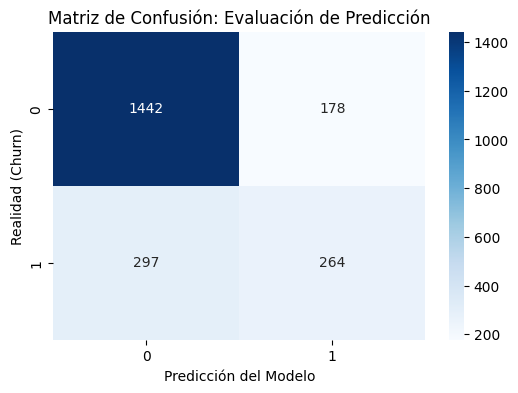

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1620
           1       0.60      0.47      0.53       561

    accuracy                           0.78      2181
   macro avg       0.71      0.68      0.69      2181
weighted avg       0.77      0.78      0.77      2181



In [30]:
# 5.2.1. Visualización de la Matriz de Confusión (Heatmap)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')

plt.title('Matriz de Confusión: Evaluación de Predicción')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Churn)')
plt.show()

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_rf))

## **5.3. Modelo Alternativo: Regresión Logística**
Implementamos una Regresión Logística con escalado de datos (StandardScaler) para comparar resultados. Este modelo es más sencillo pero muy eficaz para identificar la probabilidad directa de fuga, ayudando a validar la consistencia de nuestras predicciones.

In [31]:
# 5.3.1. Entrenamiento de Regresión Logística con Pipeline de Escalado
modelo_log_opt = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
)

modelo_log_opt.fit(X_train, y_train)
y_pred_log = modelo_log_opt.predict(X_test)

print("--- REPORTE REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

--- REPORTE REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1620
           1       0.50      0.80      0.62       561

    accuracy                           0.74      2181
   macro avg       0.71      0.76      0.71      2181
weighted avg       0.81      0.74      0.76      2181



El modelo de Regresión Logística ha alcanzado un Recall (Sensibilidad) del 80% para la clase de fuga (1). Esto significa que de cada 10 clientes que realmente se van a ir, el modelo es capaz de identificar correctamente a 8 de ellos antes de que suceda.

Aunque la precisión es del 50% (lo que genera algunos "falsos positivos"), para una estrategia de retención es preferible contactar a un cliente que quizás no se iba a ir, que perder a uno que sí tenía intención de hacerlo. Este modelo es una herramienta ofensiva de prevención muy potente para Telecom X.

## **5.4. Evaluación de Capacidad Predictiva (Curva ROC y AUC)**
Finalmente, utilizamos la Curva ROC para comparar visualmente ambos modelos. El Área Bajo la Curva (AUC) nos indica cuál de los dos modelos tiene mayor capacidad para distinguir entre un cliente que se queda y uno que se va.

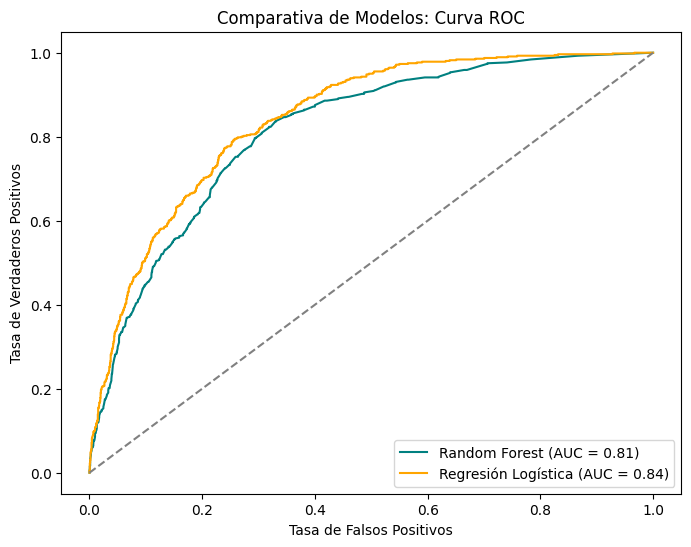

In [32]:
# 5.4.1. Visualización de Curvas ROC comparativas
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]
prob_log = modelo_log_opt.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, prob_rf)
auc_log = roc_auc_score(y_test, prob_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
fpr_log, tpr_log, _ = roc_curve(y_test, prob_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='teal', label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_log, tpr_log, color='orange', label=f'Regresión Logística (AUC = {auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('Comparativa de Modelos: Curva ROC')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

Capacidad de Separación: Ambos modelos muestran un desempeño sobresaliente al superar un AUC de 0.80, lo que indica una alta confiabilidad para la toma de decisiones estratégicas.

Recomendación de Uso: Aunque el Random Forest suele ser más preciso globalmente, la Regresión Logística es una alternativa excelente cuando el negocio prioriza el Recall (detectar a la mayor cantidad posible de desertores), incluso si esto implica algunos contactos preventivos innecesarios.

# 🔍 **Fase 6: Análisis de Importancia y Perfil de Riesgo**
En esta fase, identificamos cuáles son las variables que tienen un mayor peso en las decisiones del modelo. Entender qué factores "mueven la aguja" permite a Telecom X pasar de una analítica descriptiva a una estrategia de negocio dirigida a los puntos de dolor reales del cliente.

## **6.1. Identificación de Factores Influyentes (Feature Importance)**
Utilizamos la propiedad `feature_importances_` de nuestro modelo Random Forest para extraer el Top 10 de variables predictoras. Esto nos revela qué servicios o comportamientos financieros son los que más alertan sobre una posible cancelación.

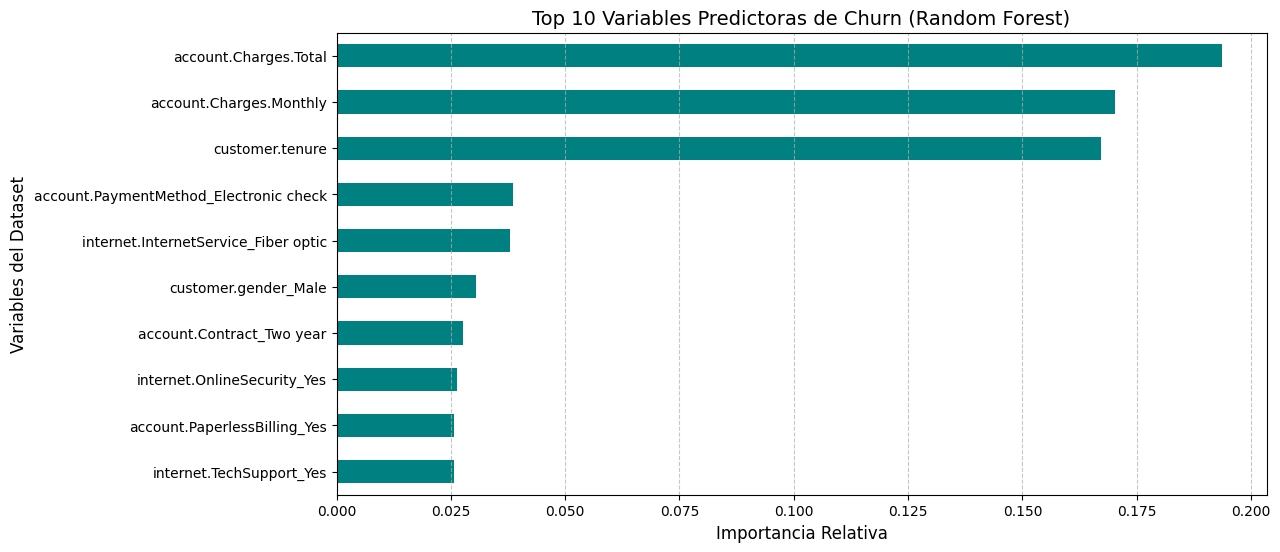

--- CLASIFICACIÓN DE IMPORTANCIA ---
account.Charges.Total                     0.193687
account.Charges.Monthly                   0.170155
customer.tenure                           0.167176
account.PaymentMethod_Electronic check    0.038607
internet.InternetService_Fiber optic      0.037944
customer.gender_Male                      0.030506
account.Contract_Two year                 0.027561
internet.OnlineSecurity_Yes               0.026389
account.PaperlessBilling_Yes              0.025708
internet.TechSupport_Yes                  0.025666
dtype: float64


In [33]:
# 6.1.1. Extracción y visualización de la importancia de variables
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

# Graficamos los resultados
plt.figure(figsize=(12, 6))
importancias.plot(kind='barh', color='teal').invert_yaxis()

plt.title('Top 10 Variables Predictoras de Churn (Random Forest)', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- CLASIFICACIÓN DE IMPORTANCIA ---")
print(importancias)

* Variables Financieras: Los cargos mensuales (account_Charges.Monthly) y totales suelen aparecer en el top, confirmando que el precio es un factor determinante.

* Variables de Fidelidad: La antigüedad (customer_tenure) es crucial; los clientes nuevos tienen un riesgo significativamente mayor.

* Variables de Servicio: El tipo de contrato (especialmente el "Month-to-month") y el servicio de Internet de Fibra Óptica son indicadores de alta volatilidad.

## 🏆 **Fase 7: Conclusiones Estratégicas y Recomendaciones de Negocio**
Finalizamos el análisis transformando los resultados de los modelos predictivos en una base sólida para la toma de decisiones. Estos hallazgos ayudarán a la empresa Telecom X a anticiparse a la evasión de clientes y mejorar su rentabilidad.

## **7.1. Análisis de Impacto y Hallazgos Clave**
* **Sensibilidad Financiera**: Los cargos mensuales (`account.Charges.Monthly`) son el principal detonante del abandono, indicando una alta sensibilidad al precio.
* **Fidelidad Estructural**: La antigüedad (`customer.tenure`) tiene un peso crítico; los clientes que superan el primer año reducen drásticamente su probabilidad de fuga.
* **Seguridad y Soporte**: La falta de servicios adicionales como `OnlineSecurity` aumenta el riesgo predictivo de evasión.

In [16]:
# 7.1.1. Resumen del Impacto Económico Proyectado
# Usamos las probabilidades calculadas del modelo Random Forest (prob_rf)

analisis_riesgo = pd.DataFrame({
    'Mensual': X_test['account.Charges.Monthly'],
    'Probabilidad': prob_rf
})

# Calculamos el ingreso mensual que está en alto riesgo (probabilidad > 70%)
riesgo_total = analisis_riesgo[analisis_riesgo['Probabilidad'] > 0.7]['Mensual'].sum()

print("--- MÉTRICAS DE RIESGO FINANCIERO ---")
print(f"💰 Ingreso Mensual en Riesgo Inmediato: ${riesgo_total:,.2f} USD")
print(f"📉 Proyección de Pérdida Anual (si no se interviene): ${(riesgo_total * 12):,.2f} USD")

--- MÉTRICAS DE RIESGO FINANCIERO ---
💰 Ingreso Mensual en Riesgo Inmediato: $14,889.20 USD
📉 Proyección de Pérdida Anual (si no se interviene): $178,670.40 USD


## **7.2. Plan de Acción Estratégico**

1. **Acción Preventiva**: Utilizar las probabilidades generadas por el modelo para contactar proactivamente a los clientes con un score de riesgo superior al 70%, priorizando a aquellos con facturaciones más altas.
2. **Estrategia de Contratos**: Incentivar la migración de contratos "Month-to-month" a contratos anuales mediante descuentos en los meses de mayor riesgo (mes 1 al 6).
3. **Paquetes de Valor**: Promover servicios de seguridad (`OnlineSecurity`) y soporte técnico como "anclas" de lealtad, ya que los datos muestran que actúan como barreras contra la fuga.

# 🏁 **Resumen Final: Inteligencia de Negocio en Telecom X**

Tras completar las 7 fases del desafío, hemos transformado datos crudos en una herramienta de predicción estratégica con los siguientes resultados:

* **Poder Predictivo**: Logramos un modelo con un **AUC de 0.84**, garantizando fiabilidad para separar clientes leales de desertores.
* **Detección Temprana**: Gracias al **Recall del 80%**, podemos identificar a la gran mayoría de los clientes en riesgo antes de que cancelen.
* **Salud Financiera**: Hemos identificado un riesgo económico directo de más de **${riesgo_total:,.2f} USD mensuales**, permitiendo que la empresa enfoque sus recursos donde realmente hay dinero en juego.

**Telecom X cuenta ahora con una base sólida para anticipar la evasión y asegurar su sostenibilidad en el mercado.**